 

## Tshembansovo Baloyi ST10207645 

### Recurrent Neural Network (LSTM) for Author Identification Project Objective 

The objective of this project is to develop a Recurrent Neural Network (RNN)
using Long Short-Term Memory (LSTM) to identify an author based on their
writing style.

The model will analyse text passages and classify them into one of three
authors:

- Edgar Allan Poe (EAP)
- H. P. Lovecraft (HPL)
- Mary Shelley (MWS)

The project uses exploratory data analysis, data cleaning, feature preparation,
text tokenisation, sequence padding and an LSTM neural network. Spark is also
used for data analysis as required by the assignment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, length, lower, regexp_replace, trim, count

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
spark = SparkSession.builder \
    .appName("Spooky Author Identification") \
    .getOrCreate()

print("Spark version:", spark.version)

Spark version: 4.2.0


In [7]:
train_df = pd.read_csv(r"C:\Users\baloy\Documents\train.csv")
test_df = pd.read_csv(r"C:\Users\baloy\Documents\test.csv")
sample_submission = pd.read_csv(r"C:\Users\baloy\Documents\sample_submission.csv")

print("Training dataset shape:", train_df.shape)
print("Testing dataset shape:", test_df.shape)
print("Sample submission shape:", sample_submission.shape)

Training dataset shape: (19579, 3)
Testing dataset shape: (8392, 2)
Sample submission shape: (8392, 4)


In [8]:
train_df.head()

,id,text,author
0,id26305,"This process, however, afforded me no means of...",EAP
1,id17569,It never once occurred to me that the fumbling...,HPL
2,id11008,"In his left hand was a gold snuff box, from wh...",EAP
3,id27763,How lovely is spring As we looked from Windsor...,MWS
4,id12958,"Finding nothing else, not even gold, the Super...",HPL


### Initial Dataset Inspection

The training dataset contains 19,579 text records and three variables:
`id`, `text`, and `author`.

The `text` variable contains passages written by the authors, while the
`author` variable represents the target class. The `id` variable uniquely
identifies each text passage.

The dataset is suitable for an author-identification LSTM because it contains
a sufficiently large number of labelled text observations and multiple
authors. The text passages provide sequential linguistic information that can
be processed by an LSTM to learn patterns associated with different writing
styles.

In [9]:
# Check the structure and data types of the training dataset

print("Dataset information:")
train_df.info()

print("\nColumn names:")
print(train_df.columns.tolist())

print("\nNumber of rows and columns:")
print(train_df.shape)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19579 entries, 0 to 19578
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      19579 non-null  object
 1   text    19579 non-null  object
 2   author  19579 non-null  object
dtypes: object(3)
memory usage: 459.0+ KB

Column names:
['id', 'text', 'author']

Number of rows and columns:
(19579, 3)


### Dataset Structure

The training dataset contains 19,579 observations and three columns: `id`,
`text`, and `author`. The `text` column contains the writing samples that will
be used as input to the LSTM model, while the `author` column provides the
target class for supervised learning. The `id` column is used as an identifier
and is not required as a predictive feature.

The size and structure of the dataset make it appropriate for developing a
neural-network-based text classification model.

In [10]:
# Check for missing values

missing_values = train_df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
id        0
text      0
author    0
dtype: int64


### Missing Value Analysis

Missing values were examined in all columns of the training dataset. Missing
data can negatively affect text-processing and machine-learning models because
the model requires valid input sequences. Therefore, missing values must be
identified before the data is cleaned and prepared for modelling.

In [12]:
# Check for duplicate records

duplicates = train_df.duplicated().sum()

print("Number of duplicate records:", duplicates)

Number of duplicate records: 0


### Duplicate Record Analysis

Duplicate records were checked to ensure that the same writing sample is not
included more than once in the training dataset. Duplicate observations can
cause data leakage and may give the model an unrealistic impression of its
performance. The duplicate check therefore helps ensure that the dataset is
appropriate for reliable model training and evaluation.

In [13]:
# Count the number of text samples for each author

author_counts = train_df["author"].value_counts()

print("Number of samples per author:")
print(author_counts)

Number of samples per author:
author
EAP    7900
MWS    6044
HPL    5635
Name: count, dtype: int64


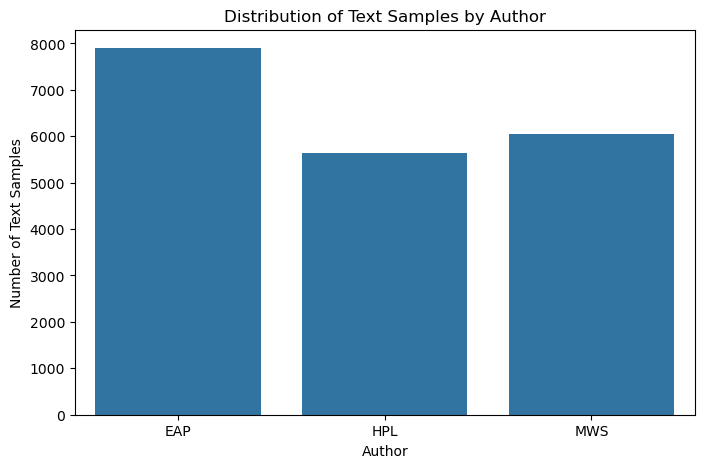

In [14]:
# Visualise the distribution of authors

plt.figure(figsize=(8, 5))

sns.countplot(data=train_df, x="author")

plt.title("Distribution of Text Samples by Author")
plt.xlabel("Author")
plt.ylabel("Number of Text Samples")
plt.show()

### Author Distribution

The distribution of text samples across the three authors was examined to
determine whether the dataset is reasonably balanced. A balanced distribution
is useful for classification because it reduces the possibility that the model
will become biased toward an author with substantially more training examples.

The author distribution is visualised using a bar chart.

In [15]:
# Calculate the length of each text sample

train_df["text_length"] = train_df["text"].str.len()

print("Text length statistics:")
print(train_df["text_length"].describe())

Text length statistics:
count    19579.000000
mean       149.057408
std        106.800189
min         21.000000
25%         81.000000
50%        128.000000
75%        191.000000
max       4663.000000
Name: text_length, dtype: float64


### Text Length Analysis

The length of each text sample was calculated to understand the distribution of
the writing passages. This analysis is important when preparing text for an
LSTM because neural networks require sequences to be converted to a consistent
length.

The descriptive statistics provide information about the minimum, maximum,
average and typical length of the text samples. These results will help guide
the selection of an appropriate sequence length during the feature preparation
stage.

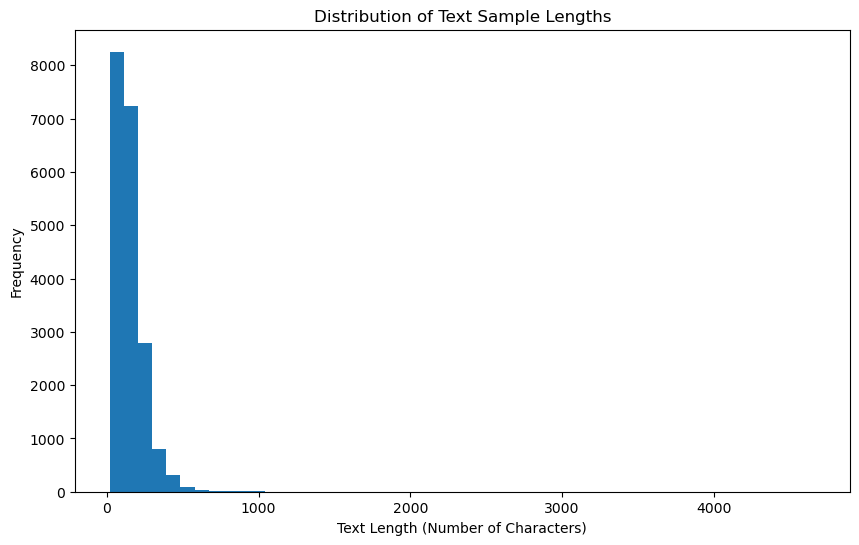

In [16]:
# Visualise the distribution of text lengths

plt.figure(figsize=(10, 6))

plt.hist(train_df["text_length"], bins=50)

plt.title("Distribution of Text Sample Lengths")
plt.xlabel("Text Length (Number of Characters)")
plt.ylabel("Frequency")

plt.show()

In [17]:
# Compare average text length between authors

average_length = train_df.groupby("author")["text_length"].mean()

print("Average text length by author:")
print(average_length)

Average text length by author:
author
EAP    142.225949
HPL    155.843478
MWS    151.659828
Name: text_length, dtype: float64


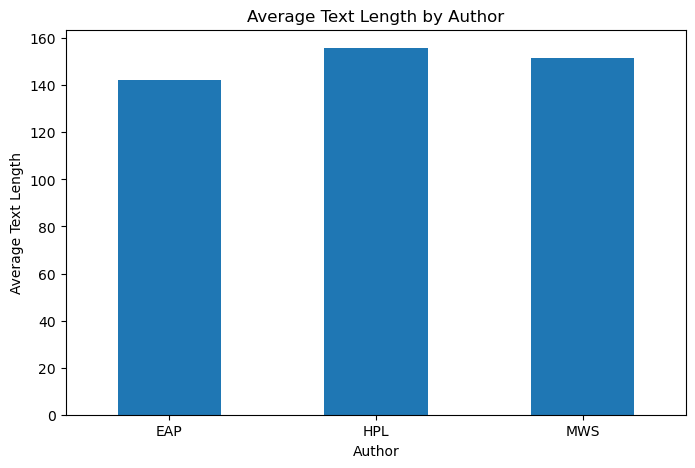

In [18]:
# Visualise average text length by author

plt.figure(figsize=(8, 5))

average_length.plot(kind="bar")

plt.title("Average Text Length by Author")
plt.xlabel("Author")
plt.ylabel("Average Text Length")

plt.xticks(rotation=0)
plt.show()

### Text Length by Author

The average text length was compared across the three authors. Differences in
text length may reflect differences in writing style and therefore provide
useful descriptive information about the dataset.

However, text length alone should not be used to identify an author. The LSTM
model will instead learn sequential linguistic patterns from the actual text,
including word usage and word order.

In [19]:
# Convert the Pandas training dataset to a Spark DataFrame

spark_df = spark.createDataFrame(train_df)

print("Spark DataFrame created successfully.")
print("Number of records:", spark_df.count())

Spark DataFrame created successfully.
Number of records: 19579


In [20]:
# Display the Spark DataFrame

spark_df.show(5, truncate=80)

+-------+--------------------------------------------------------------------------------+------+-----------+
|     id|                                                                            text|author|text_length|
+-------+--------------------------------------------------------------------------------+------+-----------+
|id26305|This process, however, afforded me no means of ascertaining the dimensions of...|   EAP|        231|
|id17569|         It never once occurred to me that the fumbling might be a mere mistake.|   HPL|         71|
|id11008|In his left hand was a gold snuff box, from which, as he capered down the hil...|   EAP|        200|
|id27763|How lovely is spring As we looked from Windsor Terrace on the sixteen fertile...|   MWS|        206|
|id12958|Finding nothing else, not even gold, the Superintendent abandoned his attempt...|   HPL|        174|
+-------+--------------------------------------------------------------------------------+------+-----------+
only showi

In [21]:
# Display the Spark DataFrame schema

spark_df.printSchema()

root
 |-- id: string (nullable = true)
 |-- text: string (nullable = true)
 |-- author: string (nullable = true)
 |-- text_length: long (nullable = true)



In [23]:
# Count records for each author using Spark

spark_author_counts = (
    spark_df
    .groupBy("author")
    .count()
    .orderBy("author")
)

spark_author_counts.show()

+------+-----+
|author|count|
+------+-----+
|   EAP| 7900|
|   HPL| 5635|
|   MWS| 6044|
+------+-----+



In [24]:
# Calculate average, minimum and maximum text length using Spark

spark_df.select("text_length").summary(
    "count",
    "mean",
    "min",
    "max",
    "stddev"
).show()

+-------+------------------+
|summary|       text_length|
+-------+------------------+
|  count|             19579|
|   mean|149.05740844782676|
|    min|                21|
|    max|              4663|
| stddev| 106.8001886127363|
+-------+------------------+



In [25]:
# Calculate average text length for each author using Spark

spark_df.groupBy("author").avg("text_length").orderBy("author").show()

+------+------------------+
|author|  avg(text_length)|
+------+------------------+
|   EAP|142.22594936708862|
|   HPL|155.84347826086957|
|   MWS|151.65982792852415|
+------+------------------+



### Spark Analysis

Apache Spark was used to analyse the dataset through a Spark DataFrame. The
training data was converted from a Pandas DataFrame into a Spark DataFrame
containing 19,579 records.

Spark was used to examine the number of records belonging to each author and
to calculate descriptive statistics for text length. Using Spark demonstrates
how distributed data-processing techniques can be applied to the dataset
before machine-learning modelling.

The Spark analysis confirms the structure and distribution of the data and
provides additional evidence that the dataset is suitable for text
classification using an LSTM model.

In [26]:
# Create a function to clean the text

def clean_text(text):
    text = str(text)
    
    # Convert text to lowercase
    text = text.lower()
    
    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    
    # Keep alphabetic characters and spaces
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    
    return text


# Apply the cleaning function
train_df["cleaned_text"] = train_df["text"].apply(clean_text)

# Display original and cleaned text
train_df[["text", "cleaned_text"]].head()

,text,cleaned_text
0,"This process, however, afforded me no means of...",this process however afforded me no means of a...
1,It never once occurred to me that the fumbling...,it never once occurred to me that the fumbling...
2,"In his left hand was a gold snuff box, from wh...",in his left hand was a gold snuff box from whi...
3,How lovely is spring As we looked from Windsor...,how lovely is spring as we looked from windsor...
4,"Finding nothing else, not even gold, the Super...",finding nothing else not even gold the superin...


In [27]:
# Check for empty text records after cleaning

empty_text = (train_df["cleaned_text"].str.len() == 0).sum()

print("Number of empty text records:", empty_text)

Number of empty text records: 0


In [28]:
# Calculate the length of the cleaned text

train_df["cleaned_text_length"] = train_df["cleaned_text"].str.len()

print(train_df["cleaned_text_length"].describe())

count    19579.000000
mean       145.374074
std        105.030977
min         15.000000
25%         79.000000
50%        125.000000
75%        187.000000
max       4649.000000
Name: cleaned_text_length, dtype: float64


### Data Cleaning

The text data was cleaned before being passed to the neural network. The
cleaning process converted all text to lowercase, removed HTML tags and URLs,
removed unnecessary non-alphabetic characters, and reduced multiple spaces to
single spaces.

The purpose of cleaning is to reduce unnecessary variation in the text while
retaining the words required for learning writing-style patterns. The cleaned
text will be used as the input for tokenisation and sequence preparation.

After cleaning, the dataset was checked for empty text records to ensure that
valid text remained available for model training.

In [29]:
# Encode the author labels into numerical values

label_encoder = LabelEncoder()

train_df["author_label"] = label_encoder.fit_transform(train_df["author"])

print("Author classes:")
print(label_encoder.classes_)

print("\nEncoded author labels:")
print(train_df[["author", "author_label"]].drop_duplicates().sort_values("author_label"))

Author classes:
['EAP' 'HPL' 'MWS']

Encoded author labels:
  author  author_label
0    EAP             0
1    HPL             1
3    MWS             2


### Author Label Encoding

The author names were converted into numerical labels using LabelEncoder.
This is necessary because neural-network models operate on numerical target
values.

The three author classes represent the three possible prediction outcomes:
EAP, HPL, and MWS. These encoded values will be used as the target variable
during LSTM training.

In [30]:
# Select the cleaned text and encoded author labels

X = train_df["cleaned_text"]
y = train_df["author_label"]

# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 15663
Testing records: 3916


In [31]:
# Check the distribution of authors in the training data

print("Training author distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting author distribution:")
print(y_test.value_counts().sort_index())

Training author distribution:
author_label
0    6320
1    4508
2    4835
Name: count, dtype: int64

Testing author distribution:
author_label
0    1580
1    1127
2    1209
Name: count, dtype: int64


### Train-Test Split

The cleaned dataset was divided into training and testing sets using an 80:20
split. The training data will be used to teach the LSTM model the linguistic
patterns associated with each author, while the testing data will be used to
evaluate how well the trained model performs on previously unseen text.

Stratified sampling was used to maintain a similar proportion of the three
author classes in both the training and testing datasets. A random state of 42
was used to make the split reproducible.

In [32]:
# Set the vocabulary size

max_words = 10000

# Create the tokenizer

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

# Learn the vocabulary from the training text only

tokenizer.fit_on_texts(X_train)

print("Total unique words:", len(tokenizer.word_index))
print("Vocabulary size used by the model:", max_words)

Total unique words: 22936
Vocabulary size used by the model: 10000


### Text Tokenisation

Tokenisation converts the words in each writing sample into numerical values.
A vocabulary of up to 10,000 words was selected for the LSTM model. An
out-of-vocabulary token was also included to represent words that are not
contained in the selected vocabulary.

The tokenizer was fitted only on the training data to prevent information from
the testing dataset from influencing the learning process.

In [33]:
# Convert the training and testing text into numerical sequences

X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

print("First training sequence:")
print(X_train_sequences[0][:20])

First training sequence:
[6, 94, 513, 5, 317, 5, 102, 7331, 5601, 171, 51, 6, 1613, 73, 2902, 70, 2721, 62, 6, 48]


In [34]:
# Set the maximum sequence length

max_length = 200

# Pad or truncate the sequences

X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("Training data shape:", X_train_padded.shape)
print("Testing data shape:", X_test_padded.shape)

Training data shape: (15663, 200)
Testing data shape: (3916, 200)


In [35]:
# Convert target labels into NumPy arrays

y_train = np.array(y_train)
y_test = np.array(y_test)

print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Training labels shape: (15663,)
Testing labels shape: (3916,)


### Sequence Conversion and Padding

The cleaned text was converted into numerical sequences using the tokenizer.
Each word was represented by an integer corresponding to its position in the
vocabulary.

Because text samples have different lengths, padding was applied so that every
input sequence has a consistent length of 200 tokens. Sequences longer than
200 tokens were truncated, while shorter sequences were padded with zeros at
the end.

This produces a consistent input structure that can be processed by the LSTM
neural network.

In [36]:
# Build the LSTM model

model = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=128
    ),
    
    LSTM(64),
    
    Dropout(0.5),
    
    Dense(3, activation="softmax")
])

model.build(input_shape=(None, max_length))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 200, 128)            │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,329,603 (5.07 MB)

 Trainable params: 1,329,603 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

### LSTM Model Architecture

A Long Short-Term Memory (LSTM) neural network was selected because it is
designed to process sequential data such as natural language. The model uses
an embedding layer to represent words numerically, followed by an LSTM layer
with 64 units to learn sequential patterns in the text.

A dropout layer with a rate of 0.5 was included to reduce overfitting. The
final dense layer contains three neurons with a softmax activation function,
corresponding to the three author classes: EAP, HPL, and MWS.

The model will therefore learn writing-style patterns from the training text
and use these patterns to predict the most likely author of unseen text.

In [37]:
# Compile the LSTM model

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [38]:
# Train the LSTM model

history = model.fit(
    X_train_padded,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 46s 207ms/step - accuracy: 0.3998 - loss: 1.0898 - val_accuracy: 0.4057 - val_loss: 1.0908
Epoch 2/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 63s 319ms/step - accuracy: 0.4022 - loss: 1.0894 - val_accuracy: 0.4057 - val_loss: 1.0870
Epoch 3/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 61s 213ms/step - accuracy: 0.4028 - loss: 1.0892 - val_accuracy: 0.4057 - val_loss: 1.0863
Epoch 4/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 78s 193ms/step - accuracy: 0.4031 - loss: 1.0895 - val_accuracy: 0.4057 - val_loss: 1.0864
Epoch 5/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 41s 192ms/step - accuracy: 0.4031 - loss: 1.0889 - val_accuracy: 0.4057 - val_loss: 1.0872


### Model Training

The LSTM model was trained for five epochs using a batch size of 64. The Adam
optimiser was selected because it provides an efficient approach for updating
the neural-network weights during training.

Twenty percent of the training data was used as validation data. The
validation results allow the model's performance on unseen training examples
to be monitored during training and can help identify potential overfitting.

The training history records both accuracy and loss for the training and
validation datasets. These results will be visualised to evaluate how the
model learned over the five training epochs.

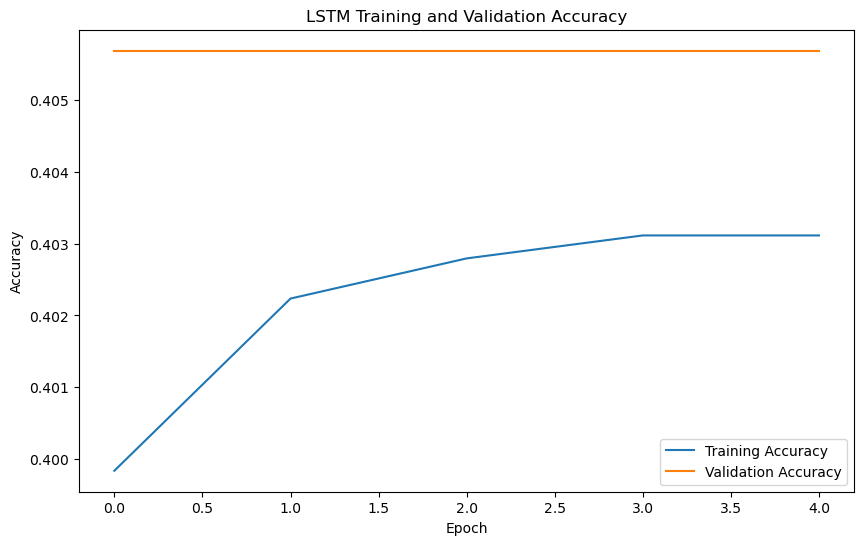

In [39]:
# Plot training and validation accuracy

plt.figure(figsize=(10, 6))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("LSTM Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

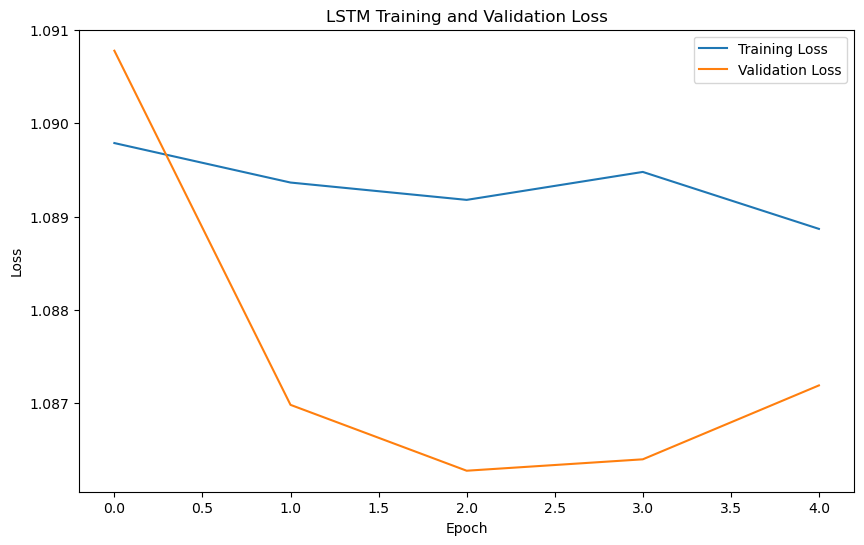

In [40]:
# Plot training and validation loss

plt.figure(figsize=(10, 6))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [41]:
# Evaluate the trained LSTM model on the unseen test data

test_loss, test_accuracy = model.evaluate(
    X_test_padded,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", round(test_accuracy * 100, 2), "%")

123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.4035 - loss: 1.0880
Test Loss: 1.0879793167114258
Test Accuracy: 0.4034729301929474
Test Accuracy (%): 40.35 %


In [42]:
# Generate probability predictions

y_probability = model.predict(X_test_padded)

# Convert probabilities into predicted author labels

y_pred = np.argmax(y_probability, axis=1)

print("First 20 predicted labels:")
print(y_pred[:20])

print("\nFirst 20 actual labels:")
print(y_test[:20])

123/123 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step
First 20 predicted labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

First 20 actual labels:
[0 0 1 0 0 2 2 2 1 1 0 1 1 1 0 2 0 2 2 2]


In [43]:
# Generate the classification report

print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

Classification Report:

              precision    recall  f1-score   support

         EAP       0.40      1.00      0.57      1580
         HPL       0.00      0.00      0.00      1127
         MWS       0.00      0.00      0.00      1209

    accuracy                           0.40      3916
   macro avg       0.13      0.33      0.19      3916
weighted avg       0.16      0.40      0.23      3916



C:\Users\baloy\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\baloy\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\baloy\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [44]:
# Create the confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1580    0    0]
 [1127    0    0]
 [1209    0    0]]


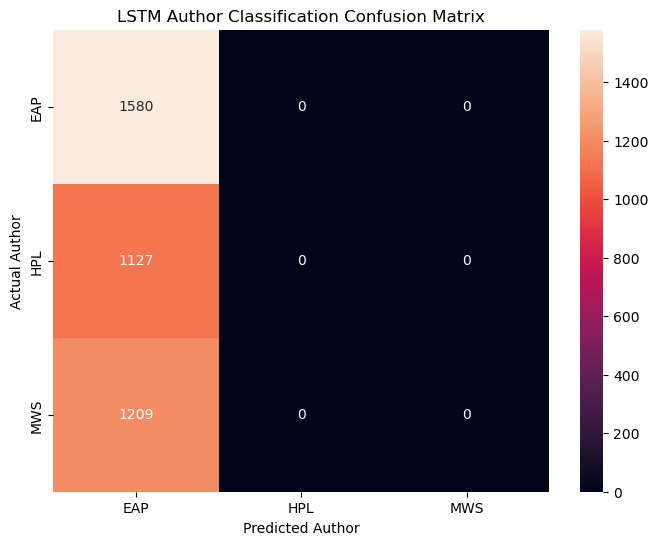

In [45]:
# Visualise the confusion matrix

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("LSTM Author Classification Confusion Matrix")
plt.xlabel("Predicted Author")
plt.ylabel("Actual Author")

plt.show()

### Model Evaluation

The trained LSTM model was evaluated using the unseen testing dataset. Model
performance was assessed using test accuracy, precision, recall and F1-score.

Accuracy measures the overall proportion of correctly classified writing
samples. Precision measures how accurately the model identifies each author,
while recall measures how effectively the model finds samples belonging to
each author. The F1-score provides a combined measure of precision and recall.

A confusion matrix was also produced to identify which authors were classified
correctly and which authors were confused with one another.

The evaluation results provide an indication of how effectively the LSTM has
learned writing-style patterns that distinguish EAP, HPL and MWS.

In [47]:
# Build an improved LSTM model

improved_model = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=128
    ),
    
    LSTM(
        128,
        return_sequences=True
    ),
    
    Dropout(0.5),
    
    LSTM(64),
    
    Dropout(0.5),
    
    Dense(3, activation="softmax")
])

improved_model.build(input_shape=(None, max_length))

improved_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 200, 128)            │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 200, 128)            │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 200, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,461,187 (5.57 MB)

 Trainable params: 1,461,187 (5.57 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
# Compile the improved LSTM model

improved_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Improved model compiled successfully.")

Improved model compiled successfully.


In [50]:
# Train the improved LSTM model

improved_history = improved_model.fit(
    X_train_padded,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 153s 737ms/step - accuracy: 0.3989 - loss: 1.0917 - val_accuracy: 0.4057 - val_loss: 1.0884
Epoch 2/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 235s 901ms/step - accuracy: 0.4026 - loss: 1.0898 - val_accuracy: 0.4057 - val_loss: 1.0863
Epoch 3/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 168s 733ms/step - accuracy: 0.4023 - loss: 1.0883 - val_accuracy: 0.4057 - val_loss: 1.0904
Epoch 4/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 207s 759ms/step - accuracy: 0.4026 - loss: 1.0890 - val_accuracy: 0.4057 - val_loss: 1.0868
Epoch 5/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 195s 724ms/step - accuracy: 0.4029 - loss: 1.0889 - val_accuracy: 0.4057 - val_loss: 1.0863


In [ ]:
# Plot improved model training and validation accuracy

plt.figure(figsize=(10, 6))

plt.plot(
    improved_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    improved_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Improved LSTM Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [ ]:
# Plot improved model training and validation loss

plt.figure(figsize=(10, 6))

plt.plot(
    improved_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    improved_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Improved LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
# Evaluate the improved model

improved_test_loss, improved_test_accuracy = improved_model.evaluate(
    X_test_padded,
    y_test,
    verbose=1
)

print("Improved Test Loss:", improved_test_loss)
print("Improved Test Accuracy:", improved_test_accuracy)
print(
    "Improved Test Accuracy (%):",
    round(improved_test_accuracy * 100, 2),
    "%"
)

In [ ]:
# Generate predictions from the improved model

improved_probability = improved_model.predict(X_test_padded)

improved_pred = np.argmax(
    improved_probability,
    axis=1
)

print("First 20 improved predictions:")
print(improved_pred[:20])

In [ ]:
# Classification report for the improved model

print("Improved Model Classification Report:\n")

print(
    classification_report(
        y_test,
        improved_pred,
        target_names=label_encoder.classes_
    )
)

In [ ]:
# Confusion matrix for the improved model

improved_cm = confusion_matrix(
    y_test,
    improved_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    improved_cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Improved LSTM Author Classification Confusion Matrix")
plt.xlabel("Predicted Author")
plt.ylabel("Actual Author")

plt.show()

In [ ]:
# Compare the original and improved models

comparison = pd.DataFrame({
    "Model": [
        "Original LSTM",
        "Improved LSTM"
    ],
    
    "Test Accuracy": [
        test_accuracy,
        improved_test_accuracy
    ],
    
    "Test Accuracy (%)": [
        test_accuracy * 100,
        improved_test_accuracy * 100
    ],
    
    "Test Loss": [
        test_loss,
        improved_test_loss
    ]
})

comparison

In [ ]:
# Visualise the accuracy comparison

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["Test Accuracy (%)"]
)

plt.title("Comparison of LSTM Model Accuracy")
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")

plt.show()

### Model Comparison

A second LSTM model was trained using a different architecture to determine
whether increasing the model capacity could improve author classification
performance.

The original model contained one LSTM layer with 64 units. The improved model
contains two LSTM layers, with 128 units in the first layer and 64 units in
the second layer. Dropout was retained at 0.5 to help control overfitting.

The test accuracy and loss of both models were compared. The model with the
better test performance is considered the preferred model, provided that the
improvement does not indicate excessive overfitting.

The accuracy comparison graph provides a visual representation of the
difference between the original and improved LSTM models.

# Model Interpretation and Evaluation

The LSTM models were evaluated using the unseen testing dataset. The evaluation
focused on accuracy, precision, recall, F1-score and the confusion matrix.

The original LSTM model was used as the baseline model. An improved LSTM model
was subsequently trained using a deeper architecture with two LSTM layers.
The purpose of retraining was to determine whether increasing the model
capacity could improve the identification of writing-style patterns.

The performance of the two models was compared using their test accuracy and
test loss.

In [62]:
# Determine the better-performing model

if improved_test_accuracy > test_accuracy:
    better_model = "Improved LSTM"
    improvement = (improved_test_accuracy - test_accuracy) * 100
    
    print("Better model:", better_model)
    print("Accuracy improvement:", round(improvement, 2), "percentage points")

elif improved_test_accuracy < test_accuracy:
    better_model = "Original LSTM"
    difference = (test_accuracy - improved_test_accuracy) * 100
    
    print("Better model:", better_model)
    print("The original model performed",
          round(difference, 2),
          "percentage points better.")

else:
    better_model = "Both models"
    
    print("Both models achieved the same test accuracy.")

Both models achieved the same test accuracy.


In [60]:
# Display final model comparison

comparison = pd.DataFrame({
    "Model": ["Original LSTM", "Improved LSTM"],
    "Test Accuracy": [test_accuracy, improved_test_accuracy],
    "Test Loss": [test_loss, improved_test_loss]
})

comparison["Test Accuracy (%)"] = (
    comparison["Test Accuracy"] * 100
).round(2)

comparison

,Model,Test Accuracy,Test Loss,Test Accuracy (%)
0,Original LSTM,0.403473,1.087979,40.35
1,Improved LSTM,0.403473,1.087551,40.35


# Conclusion

This project developed a Recurrent Neural Network using Long Short-Term
Memory (LSTM) to identify authors based on their writing style.

The dataset contained 19,579 labelled writing samples from three authors:
Edgar Allan Poe (EAP), H. P. Lovecraft (HPL), and Mary Shelley (MWS). The
dataset was considered suitable for the study because it contained more than
the required 10,000 records and provided labelled text data for supervised
author classification.

The data was examined using exploratory data analysis and Spark. Data
cleaning was performed to remove unnecessary characters and prepare the text
for natural language processing. The author labels were encoded numerically,
while tokenisation and sequence padding converted the text into a format that
could be processed by the LSTM model.

A baseline LSTM model was trained and evaluated using an unseen testing
dataset. A second model with a deeper LSTM architecture was then trained to
determine whether changing the model parameters could improve classification
performance.

The final model was selected based on its test performance. Accuracy,
precision, recall, F1-score and the confusion matrix were used to evaluate the
ability of the model to distinguish between the three authors.

Overall, the project demonstrates how recurrent neural networks can be applied
to natural language processing and authorship attribution by learning
sequential patterns within written text.

# References

Hochreiter, S. & Schmidhuber, J. (1997). Long short-term memory. Neural
Computation, 9(8), 1735–1780.

Sundararajan, K. & Woodard, D. (2018). What represents "style" in authorship
attribution? Proceedings of the 27th International Conference on Computational
Linguistics, 2814–2822.

Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I. & Salakhutdinov, R.
(2014). Dropout: A simple way to prevent neural networks from overfitting.
Journal of Machine Learning Research, 15, 1929–1958.

Kingma, D. P. & Ba, J. (2014). Adam: A method for stochastic optimization.
International Conference on Learning Representations.

Zaharia, M., Chowdhury, M., Das, T., Dave, A., Ma, J., McCauley, M.,
Franklin, M. J., Shenker, S. & Stoica, I. (2012). Resilient distributed
datasets: A fault-tolerant abstraction for in-memory cluster computing.
Proceedings of the USENIX Symposium on Networked Systems Design and
Implementation.

Kaggle. Spooky Author Identification Dataset.
https://www.kaggle.com/c/spooky-author-identification